In [1]:
import numpy as np
from imageio import imread
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

def to_gray(img):
    return (0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]).astype(np.uint8)


img1 = to_gray(imread("face_front.jpg"))
img2 = to_gray(imread("face_close.jpg"))
img3 = to_gray(imread("face_45deg.jpg"))
img4 = to_gray(imread("face_masked.jpg"))


<ipython-input-1-a68195d4aabd>:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1 = to_gray(imread("face_front.jpg"))
<ipython-input-1-a68195d4aabd>:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2 = to_gray(imread("face_close.jpg"))
<ipython-input-1-a68195d4aabd>:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img3 = to_gray(imread("face_45deg.jpg"))
<ipython-input-1-a6

Distance between image1 and image2: 8.7812, similarity: 0.9404
Distance between image1 and image3: 36.0933, similarity: 0.7767
Distance between image1 and image4: 10.7050, similarity: 0.9278


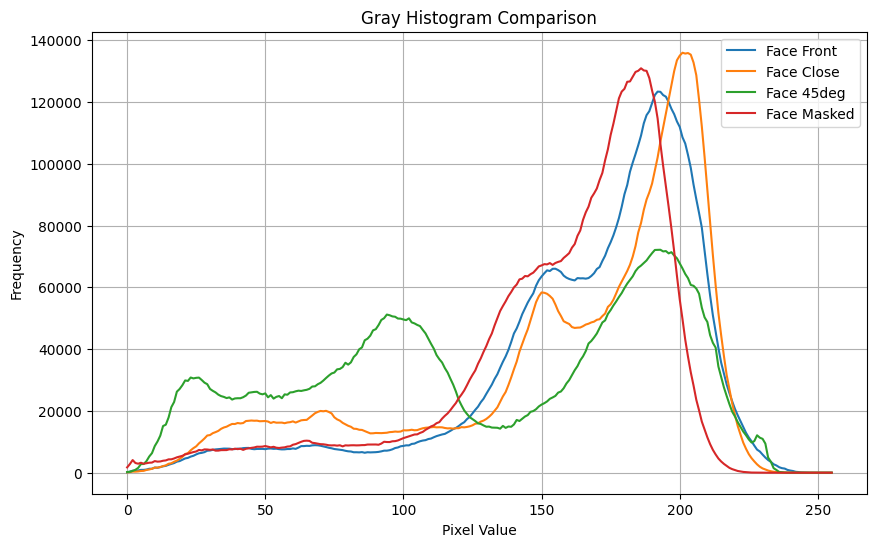

In [3]:
def compute_histogram(img):
    hist, _ = np.histogram(img, bins=256, range=(0, 256), density=False)
    return hist

hist1 = compute_histogram(img1)
hist2 = compute_histogram(img2)
hist3 = compute_histogram(img3)
hist4 = compute_histogram(img4)

bins = np.arange(256)


d12 = wasserstein_distance(bins, bins, u_weights=hist1, v_weights=hist2)
d13 = wasserstein_distance(bins, bins, u_weights=hist1, v_weights=hist3)
d14 = wasserstein_distance(bins, bins, u_weights=hist1, v_weights=hist4)

alpha = 0.007
score2 = np.exp(-alpha * d12)
score3 = np.exp(-alpha * d13)
score4 = np.exp(-alpha * d14)

print(f"Distance between image1 and image2: {d12:.4f}, similarity: {score2:.4f}")
print(f"Distance between image1 and image3: {d13:.4f}, similarity: {score3:.4f}")
print(f"Distance between image1 and image4: {d14:.4f}, similarity: {score4:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(bins, hist1, label="Face Front")
plt.plot(bins, hist2, label="Face Close")
plt.plot(bins, hist3, label="Face 45deg")
plt.plot(bins, hist4, label="Face Masked")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Gray Histogram Comparison")
plt.legend()
plt.grid(True)
plt.show()


<p>این خروجی نتیجه مقایسه با یک معیار نمایی است بر اساس فاصله وسرتین است</p>

In [4]:
!pip install keras-facenet
!pip install opencv-python
!pip install mtcnn keras-facenet opencv-python


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.5 MB/s eta 0:00:00
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=f082aef37f27a6262e4654272c0c6664f91038d3bb3d28bafedde71bfeff2708
  Stored in directory: /root/.cache/pip/wheels/99/94/dd/cb1a65a7440ba6d508bd24346c15af0b1d24ff8b1cdb1c9959
Successfully built keras-facenet


In [5]:
from keras_facenet import FaceNet
from mtcnn.mtcnn import MTCNN
import cv2
import numpy as np
from scipy.spatial.distance import euclidean

embedder = FaceNet()
detector = MTCNN()

def get_face(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)
    if not faces:
        raise ValueError(f"No face found in {img_path}")

    x, y, w, h = faces[0]['box']
    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, (160, 160))
    return face


def get_embedding(img_path):
    face = get_face(img_path)
    return embedder.embeddings([face])[0]

e1 = get_embedding("face_front.jpg")
e2 = get_embedding("face_close.jpg")
e3 = get_embedding("face_45deg.jpg")
e4 = get_embedding("face_masked.jpg")

def print_similarity(ref, other, label):
    dist = euclidean(ref, other)
    print(f"Face vs {label:<10} Distance: {dist:.4f}, Similar: {dist < 1.0}")

print_similarity(e1, e2, "Close")
print_similarity(e1, e3, "45deg")
print_similarity(e1, e4, "Masked")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Face vs Close      Distance: 0.3669, Similar: True
Face vs 45deg      Distance: 0.5276, Similar: True
Face vs Masked     Distance: 0.6730, Similar: True


<p>این خروجی نتیجه یک مدل از پیش آموزش دیده است و فاصله کمتر بیانگر شباهت بیشتر است</p>